In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from mpl_toolkits.mplot3d import Axes3D

# just so plots show inline
%matplotlib inline
print('import completed!')

import completed!


In [9]:
# Loading the already split CSV files
train_df = pd.read_csv('energyefficient_train.csv')
val_df   = pd.read_csv('energyefficient_val.csv')
test_df  = pd.read_csv('energyefficient_test.csv')

# Rename columns to match assignment notation
col_names = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'y']
train_df.columns = col_names
val_df.columns   = col_names
test_df.columns  = col_names

print(f"Train size : {len(train_df)}")
print(f"Val size   : {len(val_df)}")
print(f"Test size  : {len(test_df)}")
print("\nSample from train set:")
train_df.head()

Train size : 460
Val size   : 154
Test size  : 154

Sample from train set:


,x1,x2,x3,x4,x5,x6,x7,x8,x9,y
0,0.64,784.0,343.0,220.5,3.5,4,0.25,3,20.46,16.66
1,0.86,588.0,294.0,147.0,7.0,3,0.00,0,21.97,19.95
2,0.86,588.0,294.0,147.0,7.0,3,0.10,5,27.33,26.45
3,0.76,661.5,416.5,122.5,7.0,4,0.00,0,29.79,24.77
4,0.71,710.5,269.5,220.5,3.5,3,0.10,4,14.12,10.68


In [13]:
# Helper function 
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


In [14]:
X_train_x1 = train_df[['x1']]
y_train     = train_df['y']

X_val_x1 = val_df[['x1']]
y_val    = val_df['y']

X_test_x1 = test_df[['x1']]
y_test    = test_df['y']

# Train
lr_x1 = LinearRegression()
lr_x1.fit(X_train_x1, y_train)

print(f"Intercept  : {lr_x1.intercept_:.4f}")
print(f"Coefficient: {lr_x1.coef_[0]:.4f}")


Intercept  : -22.4704
Coefficient: 58.3585


/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


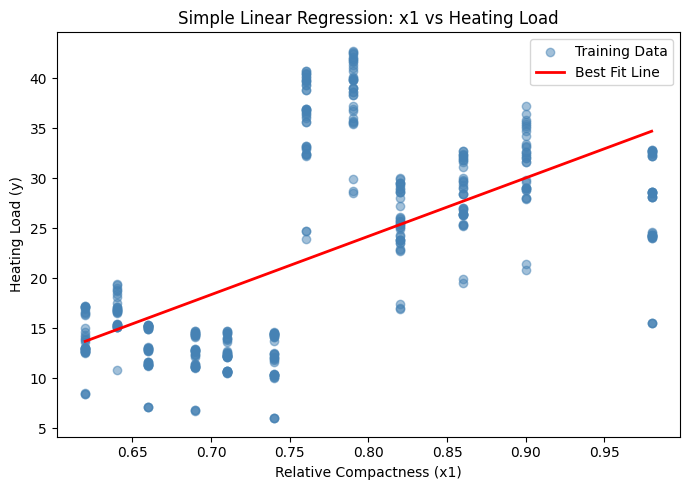

In [15]:
# Best fit line on training data
x1_range = np.linspace(train_df['x1'].min(), train_df['x1'].max(), 200).reshape(-1, 1)
y_line   = lr_x1.predict(x1_range)

plt.figure(figsize=(7, 5))
plt.scatter(train_df['x1'], y_train, alpha=0.5, color='steelblue', label='Training Data')
plt.plot(x1_range, y_line, color='red', linewidth=2, label='Best Fit Line')
plt.xlabel('Relative Compactness (x1)')
plt.ylabel('Heating Load (y)')
plt.title('Simple Linear Regression: x1 vs Heating Load')
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
# RMSE on train, val, test
train_pred_x1 = lr_x1.predict(X_train_x1)
val_pred_x1   = lr_x1.predict(X_val_x1)
test_pred_x1  = lr_x1.predict(X_test_x1)

rmse_train_x1 = rmse(y_train, train_pred_x1)
rmse_val_x1   = rmse(y_val,   val_pred_x1)
rmse_test_x1  = rmse(y_test,  test_pred_x1)

print(f"Simple LR (x1) -> Train RMSE: {rmse_train_x1:.4f} | Val RMSE: {rmse_val_x1:.4f} | Test RMSE: {rmse_test_x1:.4f}")


Simple LR (x1) -> Train RMSE: 7.9419 | Val RMSE: 8.1256 | Test RMSE: 7.5179


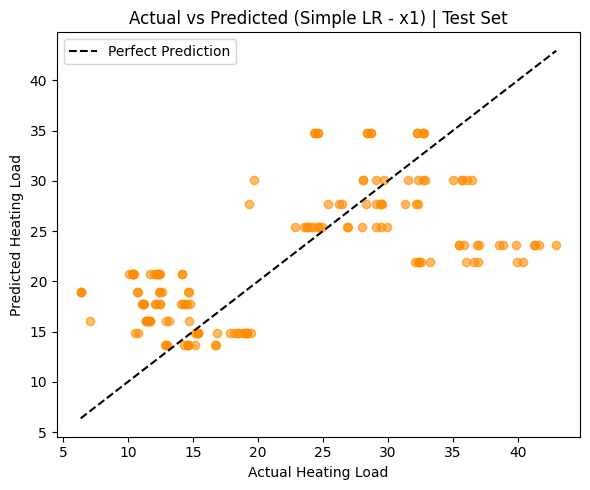

In [17]:
# Actual vs Predicted scatter — test set
plt.figure(figsize=(6, 5))
plt.scatter(y_test, test_pred_x1, alpha=0.6, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', label='Perfect Prediction')
plt.xlabel('Actual Heating Load')
plt.ylabel('Predicted Heating Load')
plt.title('Actual vs Predicted (Simple LR - x1) | Test Set')
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
degrees          = list(range(2, 12))
train_rmses_poly = []
val_rmses_poly   = []
models_poly      = []

for p in degrees:
    poly = PolynomialFeatures(degree=p)

    X_train_poly = poly.fit_transform(X_train_x1)
    X_val_poly   = poly.transform(X_val_x1)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    tr_rmse  = rmse(y_train, model.predict(X_train_poly))
    val_rmse = rmse(y_val,   model.predict(X_val_poly))

    train_rmses_poly.append(tr_rmse)
    val_rmses_poly.append(val_rmse)
    models_poly.append((model, poly))

    print(f"Degree {p:2d} | Train RMSE: {tr_rmse:.4f} | Val RMSE: {val_rmse:.4f}")


Degree  2 | Train RMSE: 7.4187 | Val RMSE: 7.6220
Degree  3 | Train RMSE: 7.0390 | Val RMSE: 7.1591
Degree  4 | Train RMSE: 6.5036 | Val RMSE: 6.4864
Degree  5 | Train RMSE: 6.4987 | Val RMSE: 6.4891
Degree  6 | Train RMSE: 5.4118 | Val RMSE: 5.2642
Degree  7 | Train RMSE: 5.4107 | Val RMSE: 5.2646
Degree  8 | Train RMSE: 4.7801 | Val RMSE: 4.5916
Degree  9 | Train RMSE: 3.9154 | Val RMSE: 3.9193
Degree 10 | Train RMSE: 3.7795 | Val RMSE: 3.7914
Degree 11 | Train RMSE: 3.1537 | Val RMSE: 3.2581


/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465

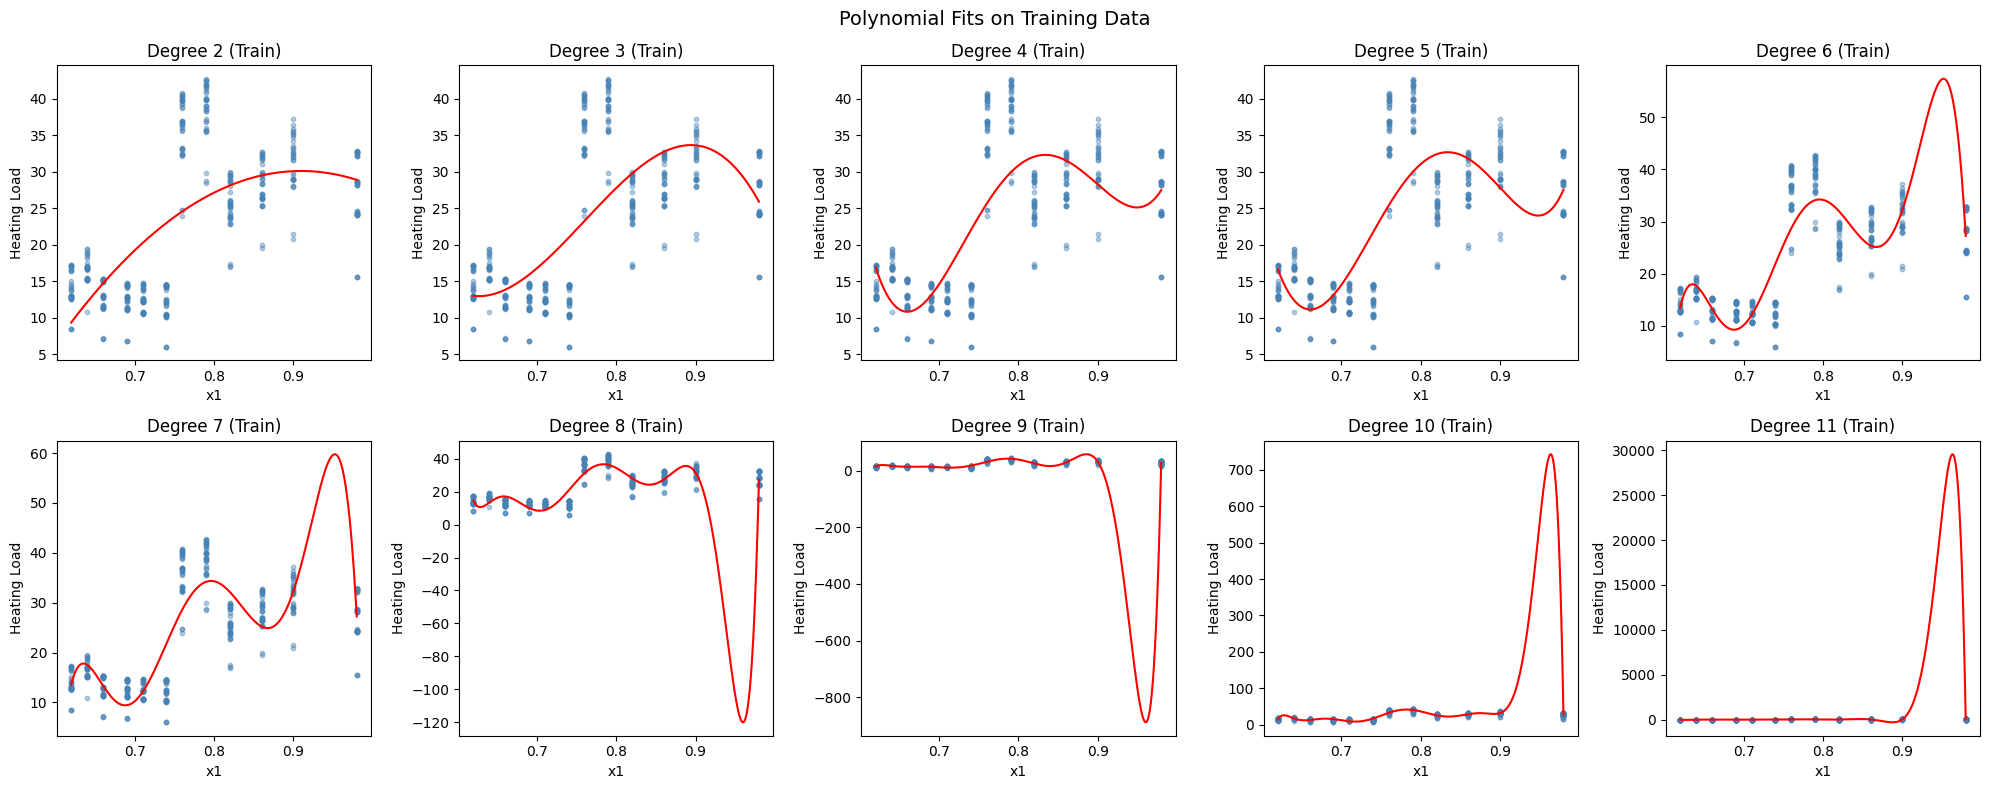

In [20]:
# Best fit curves on TRAINING data
x1_plot = np.linspace(train_df['x1'].min(), train_df['x1'].max(), 300).reshape(-1, 1)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, (p, (model, poly)) in enumerate(zip(degrees, models_poly)):
    y_plot = model.predict(poly.transform(x1_plot))
    axes[i].scatter(train_df['x1'], y_train, alpha=0.4, s=10, color='steelblue')
    axes[i].plot(x1_plot, y_plot, color='red', linewidth=1.5)
    axes[i].set_title(f'Degree {p} (Train)')
    axes[i].set_xlabel('x1')
    axes[i].set_ylabel('Heating Load')

plt.suptitle('Polynomial Fits on Training Data', fontsize=14)
plt.tight_layout()
plt.show()

/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465

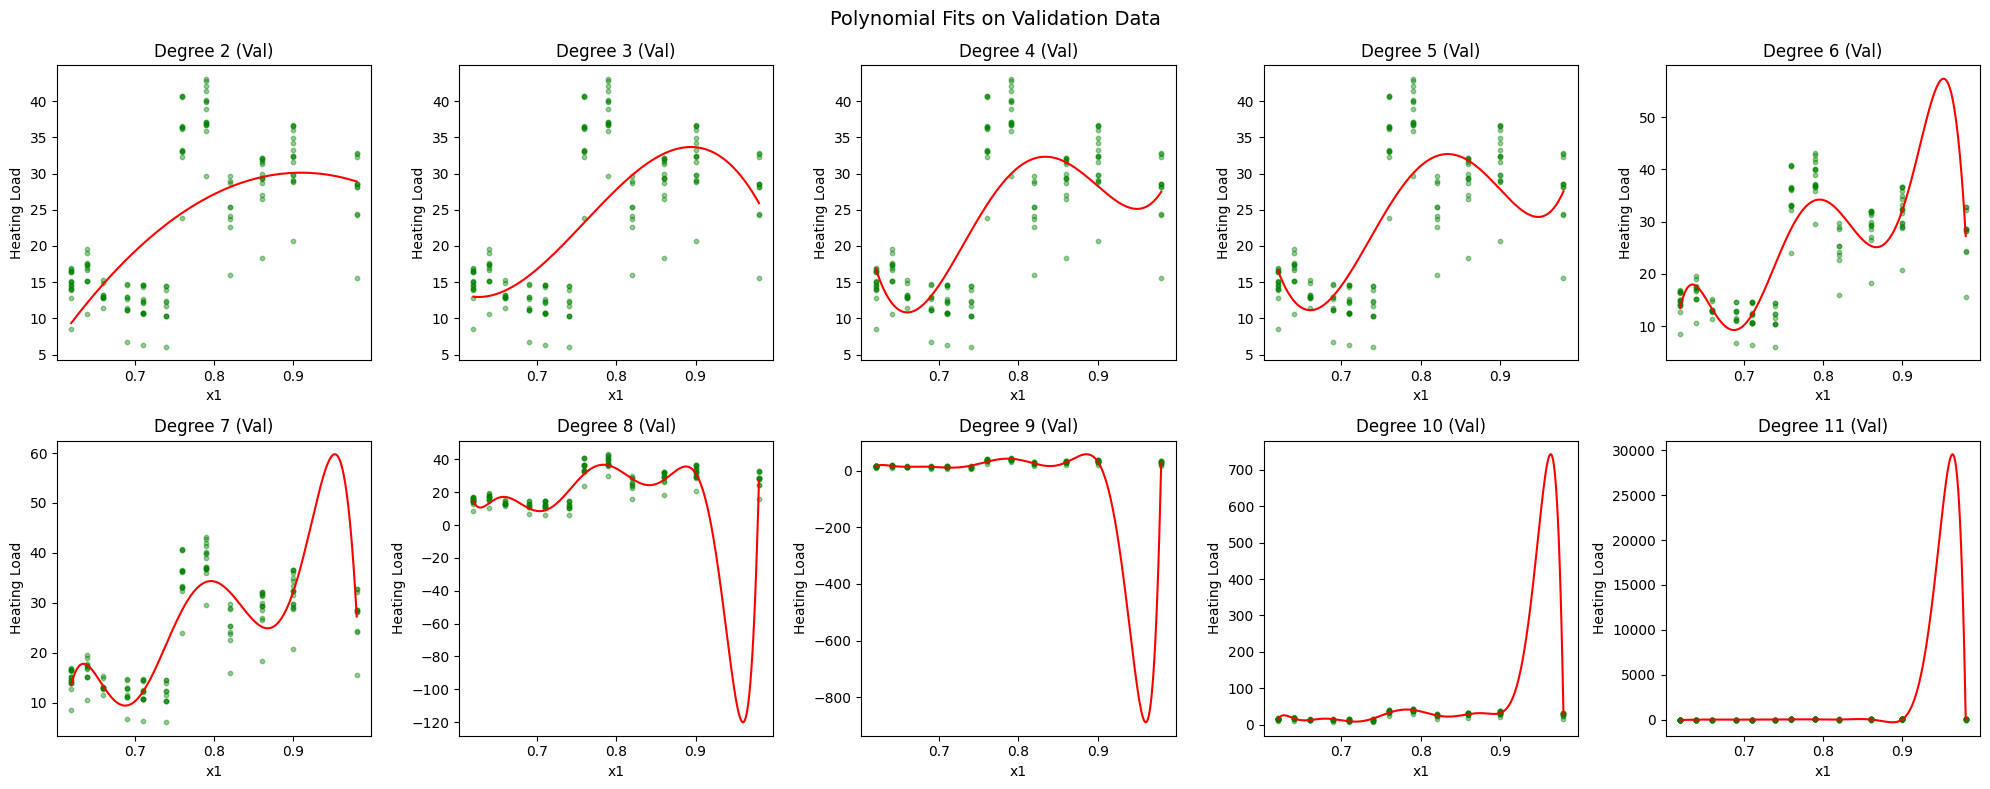

In [21]:
# Best fit curves on VALIDATION data
x1_val_plot = np.linspace(val_df['x1'].min(), val_df['x1'].max(), 300).reshape(-1, 1)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, (p, (model, poly)) in enumerate(zip(degrees, models_poly)):
    y_plot = model.predict(poly.transform(x1_val_plot))
    axes[i].scatter(val_df['x1'], y_val, alpha=0.4, s=10, color='green')
    axes[i].plot(x1_val_plot, y_plot, color='red', linewidth=1.5)
    axes[i].set_title(f'Degree {p} (Val)')
    axes[i].set_xlabel('x1')
    axes[i].set_ylabel('Heating Load')

plt.suptitle('Polynomial Fits on Validation Data', fontsize=14)
plt.tight_layout()
plt.show()

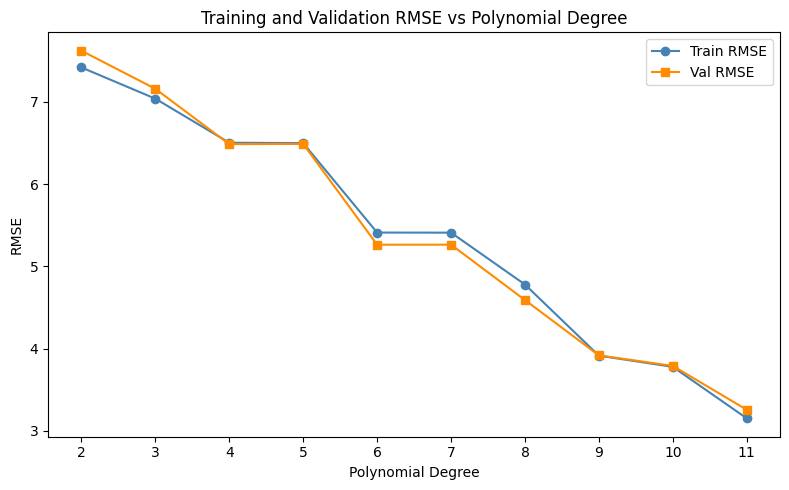

In [22]:
# RMSE vs Polynomial Degree
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_rmses_poly, marker='o', label='Train RMSE', color='steelblue')
plt.plot(degrees, val_rmses_poly,   marker='s', label='Val RMSE',   color='darkorange')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('Training and Validation RMSE vs Polynomial Degree')
plt.legend()
plt.xticks(degrees)
plt.tight_layout()
plt.show()


In [24]:
# Select best degree based on lowest validation RMSE
best_idx    = np.argmin(val_rmses_poly)
best_degree = degrees[best_idx]
best_model, best_poly = models_poly[best_idx]

print(f"Best polynomial degree : {best_degree}")
print(f"Validation RMSE        : {val_rmses_poly[best_idx]:.4f}")

# Evaluate on test
X_test_poly    = best_poly.transform(X_test_x1)
test_pred_poly = best_model.predict(X_test_poly) #predict
rmse_test_poly = rmse(y_test, test_pred_poly) # compute RMSE

print(f"Test RMSE (degree {best_degree}) : {rmse_test_poly:.4f}")


Best polynomial degree : 11
Validation RMSE        : 3.2581
Test RMSE (degree 11) : 2.8123


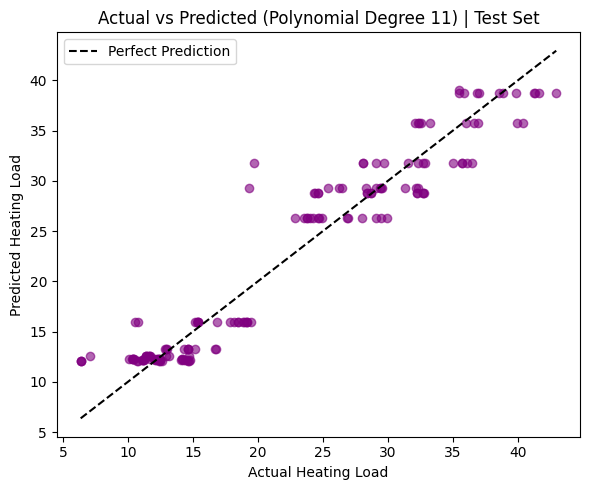

In [25]:
# Actual vs Predicted — best polynomial model on test set
plt.figure(figsize=(6, 5))
plt.scatter(y_test, test_pred_poly, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', label='Perfect Prediction')
plt.xlabel('Actual Heating Load')
plt.ylabel('Predicted Heating Load')
plt.title(f'Actual vs Predicted (Polynomial Degree {best_degree}) | Test Set')
plt.legend()
plt.tight_layout()
plt.show()


In [26]:
feature_cols = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

X_train_all = train_df[feature_cols]
X_val_all   = val_df[feature_cols]
X_test_all  = test_df[feature_cols]

lr_all = LinearRegression()
lr_all.fit(X_train_all, y_train)

train_pred_all = lr_all.predict(X_train_all)
val_pred_all   = lr_all.predict(X_val_all)
test_pred_all  = lr_all.predict(X_test_all)

rmse_train_all = rmse(y_train, train_pred_all)
rmse_val_all   = rmse(y_val,   val_pred_all)
rmse_test_all  = rmse(y_test,  test_pred_all)

print(f"Multiple LR (All Features) -> Train RMSE: {rmse_train_all:.4f} | Val RMSE: {rmse_val_all:.4f} | Test RMSE: {rmse_test_all:.4f}")


Multiple LR (All Features) -> Train RMSE: 1.6730 | Val RMSE: 2.1215 | Test RMSE: 1.7119


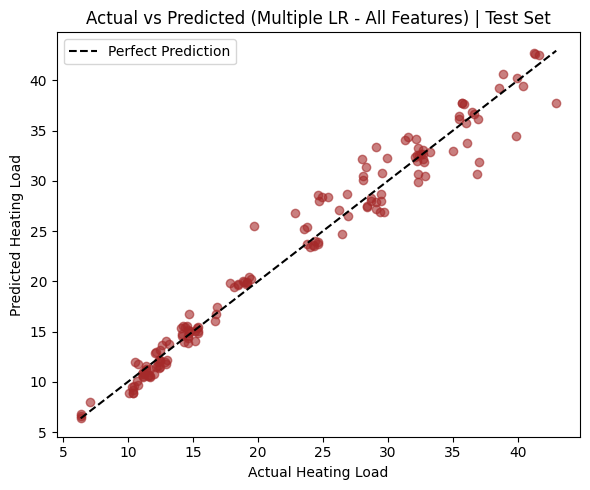

In [38]:
# Actual vs Predicted — all features on test set
plt.figure(figsize=(6, 5))
plt.scatter(y_test, test_pred_all, alpha=0.6, color='brown')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', label='Perfect Prediction')
plt.xlabel('Actual Heating Load')
plt.ylabel('Predicted Heating Load')
plt.title('Actual vs Predicted (Multiple LR - All Features) | Test Set')
plt.legend()
plt.tight_layout()
plt.show()


Correlation of each feature with Heating Load (y):
x9    0.975862
x5    0.889430
x1    0.622272
x3    0.455671
x7    0.269842
x8    0.087368
x6   -0.002587
x2   -0.658120
x4   -0.861828


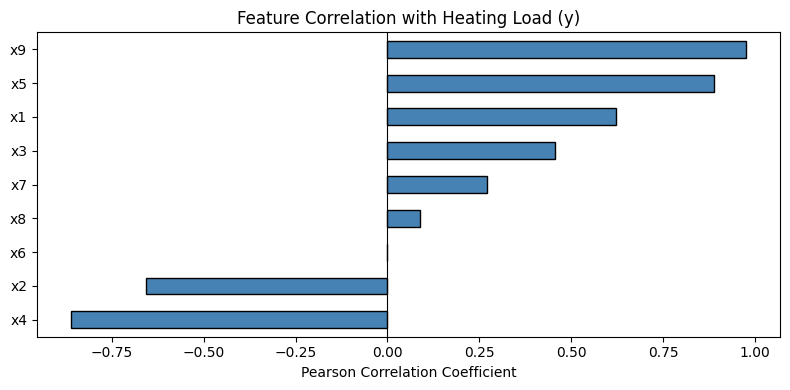

In [39]:
# Combine all splits for global correlation (use full data)
full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

correlations = full_df[feature_cols + ['y']].corr()['y'].drop('y')

print("Correlation of each feature with Heating Load (y):")
print(correlations.sort_values(ascending=False).to_string())

# Bar chart
plt.figure(figsize=(8, 4))
correlations.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson Correlation Coefficient')
plt.title('Feature Correlation with Heating Load (y)')
plt.tight_layout()
plt.show()


In [40]:
# Feature with highest absolute correlation
x_best = correlations.abs().idxmax()
print(f"Feature with highest |correlation| with y : {x_best}")
print(f"Correlation value                         : {correlations[x_best]:.4f}")


Feature with highest |correlation| with y : x9
Correlation value                         : 0.9759


In [41]:
X_train_best = train_df[[x_best]]
X_val_best   = val_df[[x_best]]
X_test_best  = test_df[[x_best]]

lr_best = LinearRegression()
lr_best.fit(X_train_best, y_train)

print(f"Training on feature : {x_best}")
print(f"Intercept           : {lr_best.intercept_:.4f}")
print(f"Coefficient         : {lr_best.coef_[0]:.4f}")


Training on feature : x9
Intercept           : -3.0498
Coefficient         : 1.0313


/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


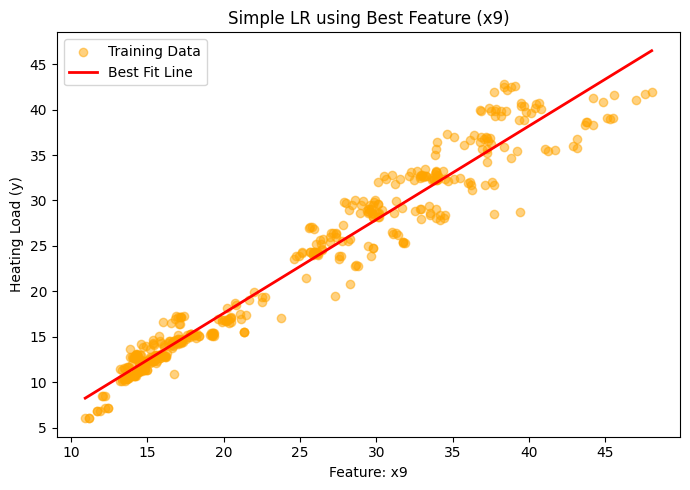

In [45]:
# Best fit line on training data
x_range = np.linspace(train_df[x_best].min(), train_df[x_best].max(), 200).reshape(-1, 1)
y_line  = lr_best.predict(x_range)

plt.figure(figsize=(7, 5))
plt.scatter(train_df[x_best], y_train, alpha=0.5, color='orange', label='Training Data')
plt.plot(x_range, y_line, color='red', linewidth=2, label='Best Fit Line')
plt.xlabel(f'Feature: {x_best}')
plt.ylabel('Heating Load (y)')
plt.title(f'Simple LR using Best Feature ({x_best})')
plt.legend()
plt.tight_layout()
plt.show()


In [46]:
train_pred_best = lr_best.predict(X_train_best)
val_pred_best   = lr_best.predict(X_val_best)
test_pred_best  = lr_best.predict(X_test_best)

rmse_train_best = rmse(y_train, train_pred_best)
rmse_val_best   = rmse(y_val,   val_pred_best)
rmse_test_best  = rmse(y_test,  test_pred_best)

print(f"Simple LR ({x_best}) -> Train RMSE: {rmse_train_best:.4f} | Val RMSE: {rmse_val_best:.4f} | Test RMSE: {rmse_test_best:.4f}")


Simple LR (x9) -> Train RMSE: 2.1536 | Val RMSE: 2.3382 | Test RMSE: 2.2067


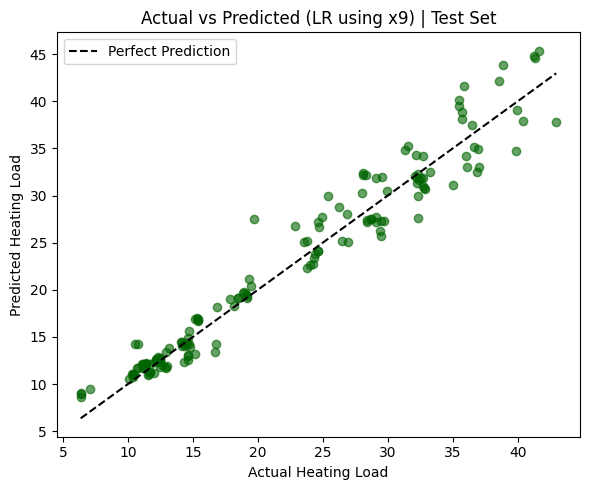

In [47]:
# Actual vs Predicted — best single feature on test set
plt.figure(figsize=(6, 5))
plt.scatter(y_test, test_pred_best, alpha=0.6, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', label='Perfect Prediction')
plt.xlabel('Actual Heating Load')
plt.ylabel('Predicted Heating Load')
plt.title(f'Actual vs Predicted (LR using {x_best}) | Test Set')
plt.legend()
plt.tight_layout()
plt.show()


In [48]:
top2 = correlations.abs().nlargest(2).index.tolist()
print(f"Top 2 features by |correlation| : {top2}")
print(f"Correlation values              : {correlations[top2].to_dict()}")


Top 2 features by |correlation| : ['x9', 'x5']
Correlation values              : {'x9': 0.9758617391437698, 'x5': 0.8894304644356397}


In [49]:
X_train_2d = train_df[top2]
X_val_2d   = val_df[top2]
X_test_2d  = test_df[top2]

lr_top2 = LinearRegression()
lr_top2.fit(X_train_2d, y_train)

print(f"Intercept   : {lr_top2.intercept_:.4f}")
print(f"Coefficients: {dict(zip(top2, lr_top2.coef_))}")


Intercept   : -3.6023
Coefficients: {'x9': 0.95768278231311, 'x5': 0.44877769005117407}


/home/user/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


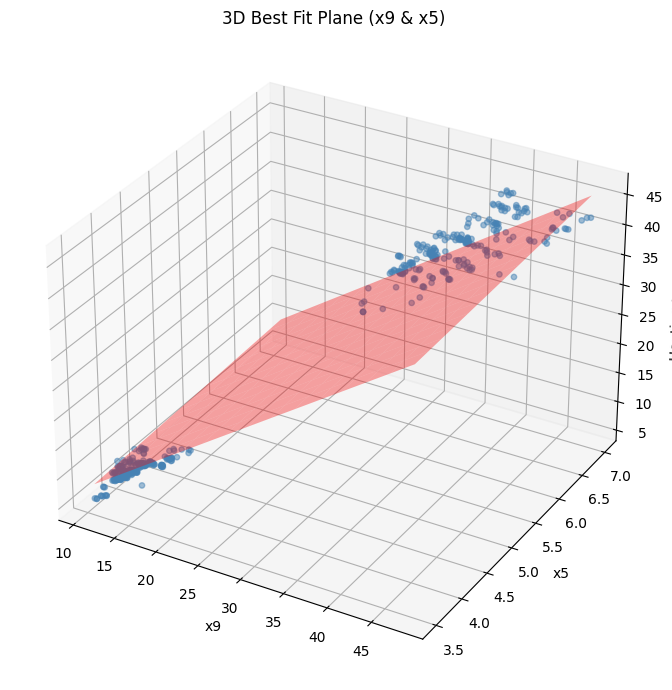

In [54]:
# 3D scatter + best fit plane on training data
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

feat1 = X_train_2d.iloc[:, 0]
feat2 = X_train_2d.iloc[:, 1]

ax.scatter(feat1, feat2, y_train, color='steelblue', alpha=0.5, s=15, label='Actual Data')

x1_range = np.linspace(feat1.min(), feat1.max(), 15)
x2_range = np.linspace(feat2.min(), feat2.max(), 15)
xx1, xx2 = np.meshgrid(x1_range, x2_range)

zz = lr_top2.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)
ax.plot_surface(xx1, xx2, zz, color='red', alpha=0.35)

ax.set_xlabel(top2[0])
ax.set_ylabel(top2[1])
ax.set_zlabel('Heating Load (y)')
ax.set_title(f'3D Best Fit Plane ({top2[0]} & {top2[1]})')
plt.tight_layout()
plt.show()


In [55]:
train_pred_top2 = lr_top2.predict(X_train_2d)
val_pred_top2   = lr_top2.predict(X_val_2d)
test_pred_top2  = lr_top2.predict(X_test_2d)

rmse_train_top2 = rmse(y_train, train_pred_top2)
rmse_val_top2   = rmse(y_val,   val_pred_top2)
rmse_test_top2  = rmse(y_test,  test_pred_top2)

print(f"Multiple LR (Top-2) -> Train RMSE: {rmse_train_top2:.4f} | Val RMSE: {rmse_val_top2:.4f} | Test RMSE: {rmse_test_top2:.4f}")


Multiple LR (Top-2) -> Train RMSE: 2.1239 | Val RMSE: 2.3551 | Test RMSE: 2.1380


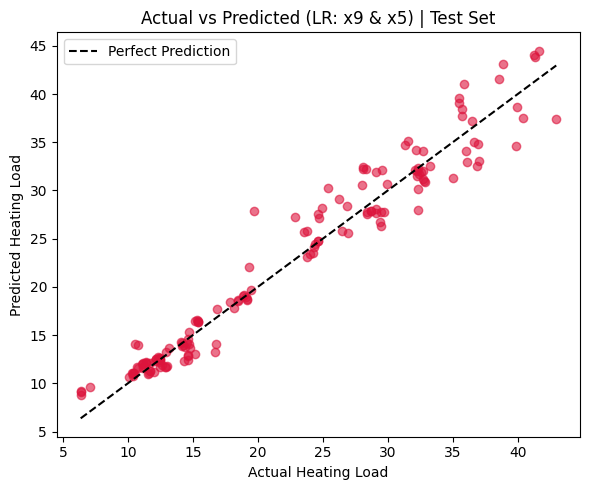

In [56]:
# Actual vs Predicted — top-2 features on test set
plt.figure(figsize=(6, 5))
plt.scatter(y_test, test_pred_top2, alpha=0.6, color='crimson')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', label='Perfect Prediction')
plt.xlabel('Actual Heating Load')
plt.ylabel('Predicted Heating Load')
plt.title(f'Actual vs Predicted (LR: {top2[0]} & {top2[1]}) | Test Set')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
comparison = pd.DataFrame({
    'Model': [
        'Simple LR (x1 - Relative Compactness)',
        f'Polynomial LR (Degree {best_degree}, x1)',
        f'Simple LR (Best Feature: {x_best})',
        f'Multiple LR (Top-2: {top2[0]} & {top2[1]})',
        'Multiple LR (All 9 Features)'
    ],
    'Test RMSE': [
        round(rmse_test_x1,   4),
        round(rmse_test_poly, 4),
        round(rmse_test_best, 4),
        round(rmse_test_top2, 4),
        round(rmse_test_all,  4),
    ]
})

print(comparison.to_string(index=False))

In [57]:
comparsion = pd.DataFrame({
    'Model':[
        'simple LR (x1 - Relative Compactness)',
        f'Polynomail LR (Degree {best_degree} , x1)',
        f'simple LR (Best Feature: {x_best})',
        f'Multiple LR (Top-2: {top2[0]}&
    ]
})